# Geolocation and Regional Analysis

## BUSINESS CASE

1. State mana yang menghasilkan revenue terbesar sebagai asal pelanggan?
2. Bagaimana perbandingan revenue antara pelanggan di São Paulo & Rio vs kota lainnya?
3. Apakah jarak antara seller dan customer berkorelasi dengan waktu pengiriman?


## IMPORT LIBRARY

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

## GATHERING DATA

In [2]:
order = pd.read_csv('https://raw.githubusercontent.com/adinfir/data-new/refs/heads/main/E-commerce-public-dataset/orders_dataset.csv')
customer = pd.read_csv('https://raw.githubusercontent.com/adinfir/data-new/refs/heads/main/E-commerce-public-dataset/customers_dataset.csv')
order_items = pd.read_csv('https://raw.githubusercontent.com/adinfir/data-new/refs/heads/main/E-commerce-public-dataset/order_items_dataset.csv')
seller = pd.read_csv('https://raw.githubusercontent.com/adinfir/data-new/refs/heads/main/E-commerce-public-dataset/sellers_dataset.csv')
geolocation = pd.read_csv('https://raw.githubusercontent.com/adinfir/data-new/refs/heads/main/E-commerce-public-dataset/geolocation_dataset.csv')

## DATA UNDERSTANDING

In [3]:
order.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
order_items.head(5)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [5]:
customer.head(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [6]:
seller.head(5)

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [7]:
geolocation.head(5)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


### GRAIN

1. tabel order : 1 row merepresntasikan 1 order
2. tabel order_items : 1 row mempresentasikan item dalam sebuah order
3. tabel seller : 1 row mempresentasikan 1 seller
4. tabel customer : 1 row mempresentasikan 1 pelanggan atau customer
5. tabel geolocation : 1 row merepresentasikan 1 record lokasi geografis berdasarkan geolocation_zip_code_prefix, city, state, latitude, dan longitude. Satu ZIP prefix dapat memiliki beberapa koordinat.

### KEY COLUMN 

1. **Tabel `orders`**:
   - `order_id` → identifier untuk setiap order
   - `customer_id` → identifier customer digunakan untuk menghubungkan tabel `order` dengan tabel `customer`
   - `order_status` → status order
   - `order_purchase_timestamp` → waktu saat customer melakukan order
   - `order_delivered_customer_date` → waktu saat pelanggan menerima barang

2. **Tabel `order_items`**:
   - `order_id` → identifier order, digunakan untuk menghubungkan tabel `order_items` dengan tabel `orders`
   - `order_item_id` → identifier order item id
   - `seller_id` → identifier seller, digunakan untuk menghubungkan tabel `order_items` dengan tabel `seller`
   - `price` → harga item

3. **Tabel `customer`**:
   - `customer_id` → identifier untuk setiap customer
   - `customer_unique_id` → ID yang merepresentasikan customer yang sebenarnya/unik
   - `customer_zip_code_prefix` → kode pos tiap customer
   - `customer_state` → state tiap customer
   - `customer_city` → city tiap customer
     
4. **Tabel `seller`**
   - `seller_id` → identifier untuk setiap seller
   - `seller_zip_code_prefix` → kode pos tiap seller
   - `seller_state` → state tiap seller
   - `seller_city` → city tiap seller

5. **Tabel `geolocation`**
   - `geolocation_zip_code_prefix` → zip code tiap location, digunakan untuk menghubungkan tabel `geolocation` dengan tabel `customer` dan tabel `seller`
   - `geolocation_state` → state tiap location, digunakan untuk menghubungkan tabel `geolocation` dengan tabel `customer` dan tabel `seller`
   - `geolocation_city` → city tiap location, digunakan untuk menghubungkan tabel `geolocation` dengan tabel `customer` dan tabel `seller`
   - `geolocation_lat` → latitude tiap location
   - `geolocation_long` → longitude tiap location 

### RELATIONSHIP TABLE

- Tabel `order` dan `order_items` terhubung melalui `order_id`.
- Tabel `order` dan `customer` terhubung melalui `customer_id`.
- Tabel `order_items` dan `seller` terhubung melalui `seller_id`.
- tabel `customer` dan `geolocation` terhubung melalui `zip_code_prefix` , `city`, dan `state.
- tabel `seller` dan `geolocation` terhubung melalui `zip_code_prefix` , `city`, dan `state`.
- Relationship dengan `geolocation` bersifat berbasis lokasi, karena satu kode pos dapat memiliki beberapa titik koordinat yang mewakili area geografis yang sama.

- `order` memiliki hubungan **one-to-many (1:N)** dengan `order_items`, karena satu order dapat memiliki beberapa item.
- `order` memiliki hubungan **many-to-one (N:1)** dengan `customer`, karena satu customer dapat memiliki beberapa order.
- `order_items` memiliki hubungan **one-to-many (1:N)** dengan `seller`, karena satu seller dapat memiliki beberapa order_items.
- `customer` memiliki hubungan many-to-many (N:M) dengan `geolocation`, karena satu area customer dapat memiliki beberapa record geolocation, dan satu area geolocation dapat digunakan oleh banyak customer.
- `seller` memiliki hubungan many-to-many (N:M) dengan `geolocation`, karena satu area seller dapat memiliki beberapa record geolocation, dan satu area geolocation dapat digunakan oleh banyak seller.

## DATA QUALITY

### ASESSING DATA

In [8]:
order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


1. Untuk kolom ```order_purchase_timestamp```,```order_approved_at```, ```order_delivered_carrier_date```, ```order_delivered_customer_date```,```order_estimated_delivery_date``` tipe data masih berbentuk object belum datetime

In [9]:
order.describe(include='all')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-04-11 10:48:14,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 23:38:46,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [10]:
print('Checking null value')
order.isna().sum()

Checking null value


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

1.  Untuk kolom ```order_approved_at```, ```order_delivered_carrier_date```, ```order_delivered_customer_date``` terdapat missing value

In [11]:
print('Checking duplicated value')
order.duplicated().sum()

Checking duplicated value


0

In [12]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [13]:
order_items.describe(include='all')

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


In [14]:
print('Checking null value')
order_items.isna().sum()

Checking null value


order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [15]:
print('Checking duplicated value')
order_items.duplicated().sum()

Checking duplicated value


0

In [16]:
seller.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [17]:
seller.describe(include='all')

,seller_id,seller_zip_code_prefix,seller_city,seller_state
count,3095,3095.000000,3095,3095
unique,3095,NaN,611,23
top,3442f8959a84dea7ee197c632cb2df15,NaN,sao paulo,SP
freq,1,NaN,694,1849
mean,NaN,32291.059451,NaN,NaN
std,NaN,32713.453830,NaN,NaN
min,NaN,1001.000000,NaN,NaN
25%,NaN,7093.500000,NaN,NaN
50%,NaN,14940.000000,NaN,NaN
75%,NaN,64552.500000,NaN,NaN


In [18]:
print('Checking null value')
seller.isna().sum()

Checking null value


seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [19]:
print('Checking duplicated value')
seller.duplicated().sum()

Checking duplicated value


0

In [20]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [21]:
customer.describe(include='all')

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,06b8999e2fba1a1fbc88172c00ba8bc7,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


In [22]:
print('Checking null value')
customer.isna().sum()

Checking null value


customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [23]:
print('Checking duplicated value')
customer.duplicated().sum()

Checking duplicated value


0

In [24]:
geolocation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [25]:
geolocation.describe(include='all')

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
count,1.000163e+06,1.000163e+06,1.000163e+06,1000163,1000163
unique,NaN,NaN,NaN,8011,27
top,NaN,NaN,NaN,sao paulo,SP
freq,NaN,NaN,NaN,135800,404268
mean,3.657417e+04,-2.117615e+01,-4.639054e+01,NaN,NaN
std,3.054934e+04,5.715866e+00,4.269748e+00,NaN,NaN
min,1.001000e+03,-3.660537e+01,-1.014668e+02,NaN,NaN
25%,1.107500e+04,-2.360355e+01,-4.857317e+01,NaN,NaN
50%,2.653000e+04,-2.291938e+01,-4.663788e+01,NaN,NaN
75%,6.350400e+04,-1.997962e+01,-4.376771e+01,NaN,NaN


In [26]:
geolocation.describe(include='all')

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
count,1.000163e+06,1.000163e+06,1.000163e+06,1000163,1000163
unique,NaN,NaN,NaN,8011,27
top,NaN,NaN,NaN,sao paulo,SP
freq,NaN,NaN,NaN,135800,404268
mean,3.657417e+04,-2.117615e+01,-4.639054e+01,NaN,NaN
std,3.054934e+04,5.715866e+00,4.269748e+00,NaN,NaN
min,1.001000e+03,-3.660537e+01,-1.014668e+02,NaN,NaN
25%,1.107500e+04,-2.360355e+01,-4.857317e+01,NaN,NaN
50%,2.653000e+04,-2.291938e+01,-4.663788e+01,NaN,NaN
75%,6.350400e+04,-1.997962e+01,-4.376771e+01,NaN,NaN


In [27]:
print('Checking null value')
geolocation.isna().sum()

Checking null value


geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

In [28]:
print('Checking duplicated value')
geolocation.duplicated().sum()

Checking duplicated value


261831

Pada tabel `geolocation` ditemukan 261.831 baris yang teridentifikasi sebagai duplicated berdasarkan seluruh kolom. Duplikasi ini tidak langsung dianggap sebagai data error karena tabel `geolocation` memiliki banyak record yang dapat merepresentasikan lokasi geografis yang sama. Oleh karena itu, duplicate tersebut tidak dihapus pada tahap ini. Pemeriksaan lebih lanjut dilakukan berdasarkan kombinasi `geolocation_zip_code_prefix`, `geolocation_city`, dan `geolocation_state` untuk memahami grain data serta variasi koordinat dalam satu area sebelum digunakan dalam perhitungan jarak antara customer dan seller.


### CLEANING DATA

## DATA PREPARATION

### MENGUBAH TIPE DATA PADA TABEL ORDER

mengubah kolom ```order_purchase_timestamp```,```order_approved_at```, ```order_delivered_carrier_date```, ```order_delivered_customer_date```,```order_estimated_delivery_date``` menjadi daatetime

In [29]:
order['order_purchase_timestamp'] = pd.to_datetime(order['order_purchase_timestamp'])
order['order_approved_at'] = pd.to_datetime(order['order_approved_at'])
order['order_delivered_carrier_date'] = pd.to_datetime(order['order_delivered_carrier_date'])
order['order_delivered_customer_date'] = pd.to_datetime(order['order_delivered_customer_date'])
order['order_estimated_delivery_date'] = pd.to_datetime(order['order_estimated_delivery_date'])

### MELAKUKAN FILTER TABEL ORDER DENGAN ORDER_STATUS = DELIVERED

In [30]:
order = order[order['order_status'] == 'delivered']

### JOIN TABLE

In [31]:
#JOIN TABEL ORDER DAN CUSTOMER
order_customer = pd.merge(
    left = order,
    right = customer,
    how = 'left',
    on = 'customer_id'
).reset_index()

In [32]:
#JOIN TABEL ORDER DAN ORDER_ITEMS
orders_items_customer = pd.merge(
    left = order_customer,
    right = order_items,
    how = 'inner',
    on = 'order_id'
)

In [33]:
orders_items_customer.isna().sum()

index                             0
order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                15
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
customer_unique_id                0
customer_zip_code_prefix          0
customer_city                     0
customer_state                    0
order_item_id                     0
product_id                        0
seller_id                         0
shipping_limit_date               0
price                             0
freight_value                     0
dtype: int64

**DATA QUALITY NOTE**
1. Setelah di filter dengan order_status = delivered seharusnya sudah tidak ada missing value dan semua kolom terisi, akan tetapi masih terdapat missing value pada kolom  ```order_approved_at```, ```order_delivered_carrier_date```, ```order_delivered_customer_date```
2. Tidak dilakukan imputasi atau penghapusan missing value pada tahap ini karena kolom tersebut tidak digunakan dalam analisis Sales & Revenue.
3. Missing value tersebut menjadi keterbatasan data yang perlu diperhatikan apabila dataset digunakan untuk analisis terkait proses dan durasi pengiriman.

### MENGAMBIL FEATURE YANG DIGUNAKAN UNTUK Q1 dan Q2

In [34]:
orders_items_q1_q2 = orders_items_customer[['order_id','order_item_id','price','customer_state']]

## EXPLORATORY DATA ANALYSIS

### 1. State mana yang menghasilkan revenue terbesar sebagai asal pelanggan?

In [35]:
state_revenue = orders_items_q1_q2.groupby('customer_state')['price'].sum().reset_index()
state_revenue.sort_values(by='price', ascending=False).head(10)

,customer_state,price
25,SP,5067633.16
18,RJ,1759651.13
10,MG,1552481.83
22,RS,728897.47
17,PR,666063.51
23,SC,507012.13
4,BA,493584.14
6,DF,296498.41
8,GO,282836.70
7,ES,268643.45


In [36]:
state_revenue = state_revenue.rename(columns={
    'customer_state': 'State Customer',
    'price' : 'Total Revenue'
    }
)
state_revenue

,State Customer,Total Revenue
0,AC,15930.97
1,AL,78855.72
2,AM,22155.84
3,AP,13374.81
4,BA,493584.14
5,CE,219757.38
6,DF,296498.41
7,ES,268643.45
8,GO,282836.70
9,MA,117009.38


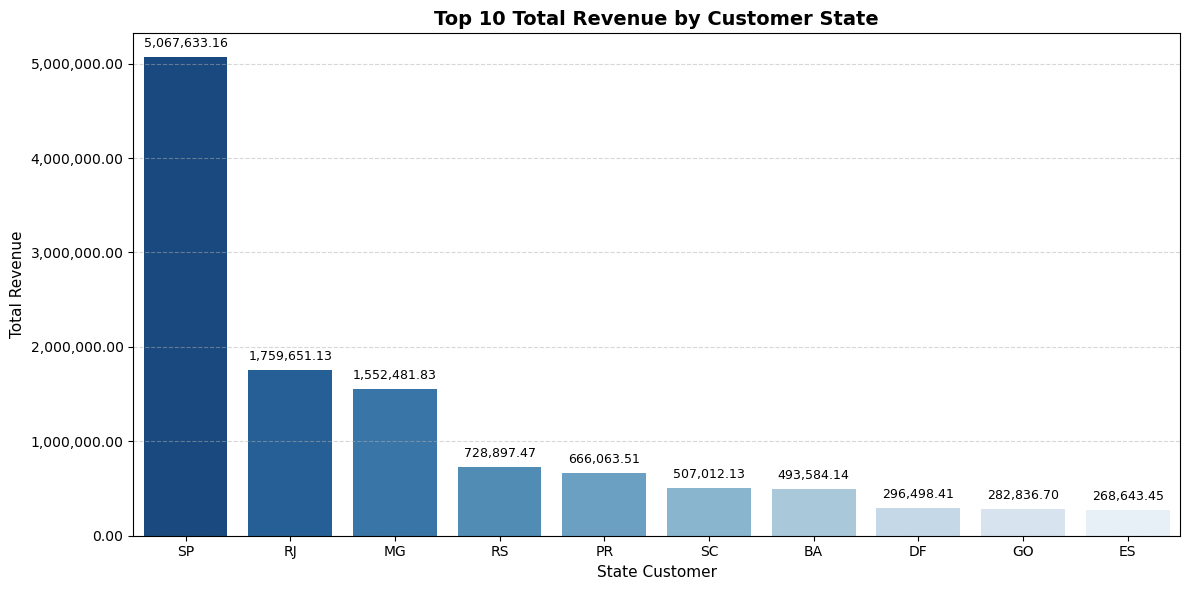

In [37]:
# 1. Mengubah angka menjadi nama hari
# Sesuaikan dictionary ini dengan format data Anda (misal 0-6 atau 1-7)
top_10_revenue = state_revenue.sort_values(by='Total Revenue', ascending=False).head(10)

# Terapkan mapping ke kolom hari (pastikan ini dijalankan sebelum plot)
plt.figure(figsize=(12, 6))

# 2. Membuat Vertical Bar Plot
# Posisi x dan y ditukar
ax = sns.barplot(
    data=top_10_revenue,
    x='State Customer',              # Sumbu X (Kategori / Nama Hari)
    y='Total Revenue',   # Sumbu Y (Angka)
    hue='State Customer',   # Parameter hue wajib dideklarasikan di Seaborn terbaru saat memakai palette
    palette='Blues_r',
    color='steelblue'      # Menggunakan satu warna solid, BUKAN gradien (palette)
)

# 3. Menambahkan Label Angka di Atas Setiap Batang
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='{:,.2f}',     
        padding=5,         
        fontsize=9
    )

# 4. Mengatasi format 1e6 pada sumbu Y (karena sumbu angka sekarang di Y)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.2f}'))

# 5. Judul dan Label Sumbu
plt.title('Top 10 Total Revenue by Customer State', fontsize=14, fontweight='bold')
plt.xlabel('State Customer', fontsize=11)
plt.ylabel('Total Revenue', fontsize=11)

# 6. Grid disesuaikan menjadi horizontal (sumbu Y)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout() 
plt.show()

#### KEY INSIGHT

1. State `SP` merupakan state dengan total revenue tertinggi dengan total revenue **R$5.067.633,16**

2. State `RJ` merupakan state dengan total revenue tertinggi kedua dengan total revenue **R$1.759.651,13**

### 2. Bagaimana perbandingan revenue antara pelanggan di São Paulo & Rio vs kota lainnya?

In [38]:
state_revenue_pct = orders_items_q1_q2.groupby('customer_state')['price'].sum().reset_index()
state_revenue_pct.sort_values(by='price', ascending=False).head(10)

,customer_state,price
25,SP,5067633.16
18,RJ,1759651.13
10,MG,1552481.83
22,RS,728897.47
17,PR,666063.51
23,SC,507012.13
4,BA,493584.14
6,DF,296498.41
8,GO,282836.70
7,ES,268643.45


In [39]:
grand_total = state_revenue_pct['price'].sum()
state_revenue_pct['pct_revenue'] = state_revenue_pct['price'] / grand_total * 100 
state_revenue_pct.sort_values(by='price', ascending=False).head(10)

,customer_state,price,pct_revenue
25,SP,5067633.16,38.328736
18,RJ,1759651.13,13.309015
10,MG,1552481.83,11.742102
22,RS,728897.47,5.512972
17,PR,666063.51,5.037731
23,SC,507012.13,3.834756
4,BA,493584.14,3.733194
6,DF,296498.41,2.242548
8,GO,282836.70,2.139218
7,ES,268643.45,2.031868


In [40]:
state_revenue_pct = state_revenue_pct.rename(columns={
    'customer_state': 'State Customer',
    'price' : 'Total Revenue'
    }
)
state_revenue_pct

,State Customer,Total Revenue,pct_revenue
0,AC,15930.97,0.120493
1,AL,78855.72,0.596420
2,AM,22155.84,0.167574
3,AP,13374.81,0.101160
4,BA,493584.14,3.733194
5,CE,219757.38,1.662122
6,DF,296498.41,2.242548
7,ES,268643.45,2.031868
8,GO,282836.70,2.139218
9,MA,117009.38,0.884993


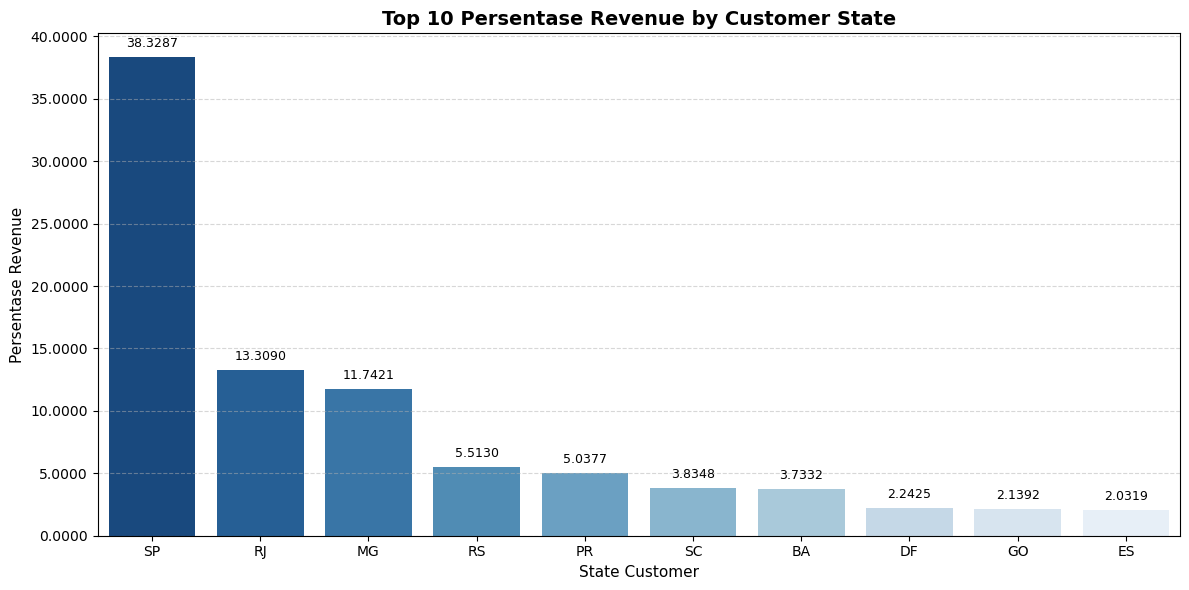

In [41]:
# 1. Mengubah angka menjadi nama hari
# Sesuaikan dictionary ini dengan format data Anda (misal 0-6 atau 1-7)
top_10_revenue_pct = state_revenue_pct.sort_values(by='Total Revenue', ascending=False).head(10)

# Terapkan mapping ke kolom hari (pastikan ini dijalankan sebelum plot)
plt.figure(figsize=(12, 6))

# 2. Membuat Vertical Bar Plot
# Posisi x dan y ditukar
ax = sns.barplot(
    data=top_10_revenue_pct,
    x='State Customer',              # Sumbu X (Kategori / Nama Hari)
    y='pct_revenue',   # Sumbu Y (Angka)
    hue='State Customer',   # Parameter hue wajib dideklarasikan di Seaborn terbaru saat memakai palette
    palette='Blues_r',
    color='steelblue'      # Menggunakan satu warna solid, BUKAN gradien (palette)
)

# 3. Menambahkan Label Angka di Atas Setiap Batang
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='{:,.4f}',     
        padding=5,         
        fontsize=9
    )

# 4. Mengatasi format 1e6 pada sumbu Y (karena sumbu angka sekarang di Y)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.4f}'))

# 5. Judul dan Label Sumbu
plt.title('Top 10 Persentase Revenue by Customer State', fontsize=14, fontweight='bold')
plt.xlabel('State Customer', fontsize=11)
plt.ylabel('Persentase Revenue', fontsize=11)

# 6. Grid disesuaikan menjadi horizontal (sumbu Y)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout() 
plt.show()

#### KEY INSIGHT

1. State `SP` merupakan state dengan persentase revenue tertinggi dengan persentase revenue **38,3287%**
2. State `RJ` merupakan state dengan persentase revenue tertinggi kedua dengan total revenue **13,3090%**

### 3. Apakah jarak antara seller dan customer berkorelasi dengan waktu pengiriman?

In [42]:
## JOIN ORDERS_ITEMS_CUSTOMER DENGAN SELLER
orders_items_customer_seller = pd.merge(
    left = orders_items_customer,
    right = seller,
    how = 'left',
    on = 'seller_id'
)

In [43]:
orders_items_customer_seller.isna().sum()

index                             0
order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                15
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
customer_unique_id                0
customer_zip_code_prefix          0
customer_city                     0
customer_state                    0
order_item_id                     0
product_id                        0
seller_id                         0
shipping_limit_date               0
price                             0
freight_value                     0
seller_zip_code_prefix            0
seller_city                       0
seller_state                      0
dtype: int64

In [44]:
geo_area = (
    geolocation
    .groupby([
        'geolocation_zip_code_prefix',
        'geolocation_city',
        'geolocation_state'
    ])
    .agg(
        lat=('geolocation_lat', 'median'),
        long=('geolocation_lng', 'median')
    )
    .reset_index()
)

In [45]:
geo_area.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27912 entries, 0 to 27911
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   geolocation_zip_code_prefix  27912 non-null  int64  
 1   geolocation_city             27912 non-null  object 
 2   geolocation_state            27912 non-null  object 
 3   lat                          27912 non-null  float64
 4   long                         27912 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 1.1+ MB


Pada tabel `geolocation` ditemukan beberapa record dengan kombinasi `zip_code_prefix`, `city`, dan `state` yang sama tetapi memiliki koordinat berbeda. Kondisi ini menunjukkan bahwa satu area dapat memiliki beberapa titik koordinat. Oleh karena itu, data tidak langsung dihapus, tetapi akan menggunakan koordinat representatif untuk setiap area pada tahap Data Preparation.


In [46]:
## MAPPING UNTUK MENGAMBIL GEOLOCATION LONGITUDE LATITUDE CUSTOMER DAN SELLER
geo_customer = geo_area.rename(columns={
    'geolocation_zip_code_prefix': 'customer_zip_code_prefix',
    'geolocation_city': 'customer_city',
    'geolocation_state': 'customer_state',
    'lat': 'customer_lat',
    'long': 'customer_long'
})

geo_seller = geo_area.rename(columns={
    'geolocation_zip_code_prefix': 'seller_zip_code_prefix',
    'geolocation_city': 'seller_city',
    'geolocation_state': 'seller_state',
    'lat': 'seller_lat',
    'long': 'seller_long'
})

In [47]:
## orders_items_customer_seller dengan geo_customer
orders_items_customer_seller_geo_cust = pd.merge(
    left = orders_items_customer_seller,
    right = geo_customer,
    how = 'left',
    on = ['customer_zip_code_prefix','customer_city','customer_state']
)

In [48]:
orders_items_customer_seller_geo_cust.isna().sum()

index                              0
order_id                           0
customer_id                        0
order_status                       0
order_purchase_timestamp           0
order_approved_at                 15
order_delivered_carrier_date       2
order_delivered_customer_date      8
order_estimated_delivery_date      0
customer_unique_id                 0
customer_zip_code_prefix           0
customer_city                      0
customer_state                     0
order_item_id                      0
product_id                         0
seller_id                          0
shipping_limit_date                0
price                              0
freight_value                      0
seller_zip_code_prefix             0
seller_city                        0
seller_state                       0
customer_lat                     332
customer_long                    332
dtype: int64

Setelah dilakukan join antara data customer dan geolocation, dilakukan pengecekan terhadap kelengkapan koordinat lokasi customer. Pemeriksaan dilakukan pada kolom `customer_lat` dan `customer_long` untuk memastikan setiap customer memiliki koordinat yang dapat digunakan dalam analisis jarak. Hasil pengecekan menunjukkan terdapat **332 baris yang memiliki nilai missing pada koordinat customer**. Data tersebut akan ditinjau lebih lanjut sebelum digunakan dalam perhitungan jarak antara customer dan seller.


In [49]:
missing_customer = orders_items_customer_seller_geo_cust[
    orders_items_customer_seller_geo_cust['customer_lat'].isna() |
    orders_items_customer_seller_geo_cust['customer_long'].isna()
][
    ['customer_zip_code_prefix', 'customer_state', 'customer_city']
].drop_duplicates()

missing_customer.info()

<class 'pandas.core.frame.DataFrame'>
Index: 171 entries, 487 to 109947
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_zip_code_prefix  171 non-null    int64 
 1   customer_state            171 non-null    object
 2   customer_city             171 non-null    object
dtypes: int64(1), object(2)
memory usage: 5.3+ KB


**CATATAN** : Setelah dilakukan pemeriksaan lebih lanjut berdasarkan customer_zip_code_prefix, customer_state, dan customer_city, terdapat 171 kombinasi lokasi unik yang memiliki koordinat missing

In [50]:
missing_zip = missing_customer[
    ['customer_zip_code_prefix']
].drop_duplicates()

missing_zip['zip_exists'] = missing_zip['customer_zip_code_prefix'].isin(
    geolocation['geolocation_zip_code_prefix']
)

missing_zip['zip_exists'].value_counts()

zip_exists
False    152
True      19
Name: count, dtype: int64

In [51]:
check_zip_state = missing_customer.merge(
    geolocation[
        ['geolocation_zip_code_prefix', 'geolocation_state']
    ].drop_duplicates(),
    left_on=['customer_zip_code_prefix', 'customer_state'],
    right_on=['geolocation_zip_code_prefix', 'geolocation_state'],
    how='left',
    indicator=True
)

check_zip_state['_merge'].value_counts()

_merge
left_only     152
both           19
right_only      0
Name: count, dtype: int64

**CATATAN** : Validasi kemudian dilakukan secara bertahap. Dari 171 kombinasi lokasi tersebut, 19 ZIP code ditemukan pada data geolocation dan memiliki kecocokan berdasarkan ZIP code dan state, sedangkan 152 ZIP code tidak ditemukan pada data geolocation. Ketika city turut digunakan sebagai kriteria pencocokan, tidak ditemukan kecocokan karena terdapat perbedaan antara informasi city pada data customer dan geolocation.

In [52]:
##TREATMENT UNTUK 19 ZIP CODE & STATE YANG ADA LAT DAN LONG
zip_19 = check_zip_state[
    check_zip_state['_merge'] == 'both'
]['customer_zip_code_prefix'].drop_duplicates()

In [53]:
zip_19.shape[0]

19

In [54]:
geo_19 = geolocation[
    geolocation['geolocation_zip_code_prefix'].isin(zip_19)
].copy()

In [55]:
geo_19_median = (
    geo_19
    .groupby([
        'geolocation_zip_code_prefix',
        'geolocation_state'
    ])
    .agg(
        customer_lat=('geolocation_lat', 'median'),
        customer_long=('geolocation_lng', 'median')
    )
    .reset_index()
)

In [56]:
geo_19_median.shape

(19, 4)

In [57]:
geo_19_median

,geolocation_zip_code_prefix,geolocation_state,customer_lat,customer_long
0,9274,SP,-23.656604,-46.497594
1,13508,SP,-22.411490,-47.570963
2,15903,SP,-21.448306,-48.574959
3,28143,RJ,-21.842513,-41.253416
4,29386,ES,-20.335973,-41.390488
5,38749,MG,-18.837118,-46.825465
6,45534,BA,-14.277952,-38.995374
7,48793,BA,-11.027780,-38.791895
8,48967,BA,-10.333614,-40.151525
9,68514,PA,-5.367055,-49.124991


In [58]:
median_lat = geo_19_median.set_index(
    ['geolocation_zip_code_prefix', 'geolocation_state']
)['customer_lat']

median_long = geo_19_median.set_index(
    ['geolocation_zip_code_prefix', 'geolocation_state']
)['customer_long']

In [59]:
geo_19_median['key'] = (
    geo_19_median['geolocation_zip_code_prefix'].astype(str)
    + '_'
    + geo_19_median['geolocation_state']
)

orders_items_customer_seller_geo_cust['key'] = (
    orders_items_customer_seller_geo_cust['customer_zip_code_prefix'].astype(str)
    + '_'
    + orders_items_customer_seller_geo_cust['customer_state']
)

In [60]:
mask = (
    orders_items_customer_seller_geo_cust['customer_lat'].isna() &
    orders_items_customer_seller_geo_cust['customer_long'].isna()
)
orders_items_customer_seller_geo_cust.loc[mask, 'customer_lat'] = (
    orders_items_customer_seller_geo_cust.loc[mask, 'key'].map(
        geo_19_median.set_index('key')['customer_lat']
    )
)

orders_items_customer_seller_geo_cust.loc[mask, 'customer_long'] = (
    orders_items_customer_seller_geo_cust.loc[mask, 'key'].map(
        geo_19_median.set_index('key')['customer_long']
    )
)

In [61]:
orders_items_customer_seller_geo_cust.isna().sum()

index                              0
order_id                           0
customer_id                        0
order_status                       0
order_purchase_timestamp           0
order_approved_at                 15
order_delivered_carrier_date       2
order_delivered_customer_date      8
order_estimated_delivery_date      0
customer_unique_id                 0
customer_zip_code_prefix           0
customer_city                      0
customer_state                     0
order_item_id                      0
product_id                         0
seller_id                          0
shipping_limit_date                0
price                              0
freight_value                      0
seller_zip_code_prefix             0
seller_city                        0
seller_state                       0
customer_lat                     288
customer_long                    288
key                                0
dtype: int64

**CATATAN** : Dari hasil validasi terhadap **171 kombinasi lokasi unik** yang memiliki koordinat customer missing, ditemukan **19 kombinasi `customer_zip_code_prefix` dan `customer_state`** yang memiliki referensi koordinat pada data geolocation. Koordinat tersebut kemudian diringkas menggunakan nilai median dan digunakan untuk mengisi `customer_lat` dan `customer_long` pada data customer yang terdampak. Setelah treatment dilakukan, jumlah missing koordinat customer berkurang dari **332 menjadi 288 baris**. Selanjutnya, dilakukan validasi terhadap 152 kombinasi customer_zip_code_prefix dan customer_state yang tidak ditemukan pada tabel geolocation sebelum menentukan treatment terhadap data customer yang terdampak.


In [62]:
## Mengambil customer yang memiliki customer_lat dan customer_long yang NaN
remaining_missing = orders_items_customer_seller_geo_cust[
    orders_items_customer_seller_geo_cust['customer_lat'].isna() |
    orders_items_customer_seller_geo_cust['customer_long'].isna()
].copy()

In [63]:
remaining_missing.shape[0]

288

In [64]:
# Melakukan pengecekan apakah customer dengan latitude/longitude yang missing
# memiliki customer_zip_code_prefix yang tersedia pada tabel geolocation
remaining_missing['zip_exists'] = (
    remaining_missing['customer_zip_code_prefix']
    .isin(geolocation['geolocation_zip_code_prefix'])
)

In [65]:
remaining_missing['zip_exists'].value_counts()

zip_exists
False    288
Name: count, dtype: int64

**CATATAN:** Setelah treatment terhadap 19 kombinasi `customer_zip_code_prefix` dan `customer_state`, masih terdapat **288 baris** dengan nilai missing pada `customer_lat` dan `customer_long`. Dilakukan validasi terhadap `customer_zip_code_prefix` untuk memastikan apakah ZIP code tersebut masih tersedia pada tabel geolocation. Hasil validasi menunjukkan bahwa **seluruh 288 baris tersebut memiliki `customer_zip_code_prefix` yang tidak ditemukan pada tabel geolocation**. Oleh karena itu, tidak tersedia referensi koordinat yang dapat digunakan untuk mengisi latitude dan longitude customer tersebut.Maka data tersebut akan di lakukan penghapusan. Maka 288 baris customer tersebut akan di-drop dari analisis jarak pada Q3.


In [66]:
# Drop customer yang tidak memiliki referensi koordinat pada geolocation
orders_items_customer_seller_geo_cust = (
    orders_items_customer_seller_geo_cust
    .drop(index=remaining_missing.index)
    .copy()
)

In [67]:
orders_items_customer_seller_geo_cust[
    ['customer_lat', 'customer_long']
].isna().sum()

customer_lat     0
customer_long    0
dtype: int64

print(f"Jumlah baris setelah drop: {len(orders_items_customer_seller_geo_cust):,}")

In [68]:
## orders_items_customer_seller dengan geo_seller
orders_items_customer_seller_geo = pd.merge(
    left = orders_items_customer_seller_geo_cust,
    right = geo_seller,
    how = 'left',
    on = ['seller_zip_code_prefix','seller_city','seller_state']
)

In [69]:
orders_items_customer_seller_geo.isna().sum()

index                               0
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date        2
order_delivered_customer_date       8
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
seller_zip_code_prefix              0
seller_city                         0
seller_state                        0
customer_lat                        0
customer_long                       0
key                                 0
seller_lat                       3007
seller_long 

**CATATAN:** Setelah proses penggabungan dengan data geolocation, ditemukan **3.007 baris** yang masih memiliki nilai missing pada `seller_lat` dan `seller_long` dari total data seller yang digunakan. Sebelum menentukan treatment, dilakukan validasi terhadap `seller_zip_code_prefix` untuk mengetahui apakah seller yang mengalami missing koordinat masih memiliki referensi lokasi pada tabel geolocation.


In [70]:
# Seller yang masih memiliki missing latitude/longitude
remaining_missing_seller = orders_items_customer_seller_geo[
    orders_items_customer_seller_geo['seller_lat'].isna() |
    orders_items_customer_seller_geo['seller_long'].isna()
].copy()

# Cek apakah seller_zip_code_prefix tersedia di geolocation
remaining_missing_seller['zip_exists'] = (
    remaining_missing_seller['seller_zip_code_prefix']
    .isin(geolocation['geolocation_zip_code_prefix'])
)

remaining_missing_seller['zip_exists'].value_counts()

zip_exists
True     2759
False     248
Name: count, dtype: int64

**CATATAN:** Dari **3.007 baris** seller yang memiliki missing `seller_lat` dan `seller_long`, sebanyak **2.759 baris** memiliki `seller_zip_code_prefix` yang ditemukan pada tabel geolocation (`True`), sedangkan **248 baris** memiliki ZIP code yang tidak ditemukan (`False`). Dengan demikian, 2.759 baris masih memiliki referensi lokasi yang dapat digunakan untuk memperoleh koordinat representatif, sedangkan 248 baris perlu dilakukan treatment secara terpisah karena tidak memiliki referensi koordinat pada tabel geolocation.


In [71]:
# Mengecek apakah kombinasi seller_zip_code_prefix dan seller_city
# tersedia pada tabel geolocation
seller_zip_city = (
    geolocation[
        ['geolocation_zip_code_prefix', 'geolocation_city']
    ]
    .drop_duplicates()
)

remaining_missing_seller['zip_city_exists'] = (
    remaining_missing_seller[
        ['seller_zip_code_prefix', 'seller_city']
    ]
    .apply(tuple, axis=1)
    .isin(
        seller_zip_city[
            ['geolocation_zip_code_prefix', 'geolocation_city']
        ]
        .apply(tuple, axis=1)
    )
)

In [72]:
remaining_missing_seller['zip_city_exists'].value_counts()

zip_city_exists
False    2380
True      627
Name: count, dtype: int64

**CATATAN:** 

1. Dari **3.007 baris** seller yang memiliki missing `seller_lat` dan `seller_long`, validasi menggunakan kombinasi `seller_zip_code_prefix` dan `seller_state` menunjukkan bahwa **2.126 baris** memiliki kombinasi ZIP code dan state yang ditemukan pada tabel geolocation, sedangkan **881 baris** tidak memiliki kombinasi tersebut. Sebanyak 2.126 baris akan dilanjutkan ke tahap penentuan koordinat representatif berdasarkan referensi geolocation, sedangkan 881 baris akan divalidasi lebih lanjut sebelum menentukan treatment.
2. Dari seller yang masih memiliki missing koordinat, dilakukan validasi berdasarkan kombinasi `seller_zip_code_prefix` dan `seller_city` terhadap tabel `geolocation`. Seller yang memiliki kombinasi lokasi yang sesuai akan diberikan koordinat representatif berdasarkan data geolocation pada area tersebut. Koordinat representatif akan dihitung menggunakan nilai median latitude dan longitude untuk setiap kombinasi ZIP code dan city.



In [73]:
## MEMISAHKAN SELLER DENGAN ZIP CITY TRUE DAN FALSE
seller_zip_city_true = remaining_missing_seller[
    remaining_missing_seller['zip_city_exists']
].copy()

seller_zip_city_false = remaining_missing_seller[
    ~remaining_missing_seller['zip_city_exists']
].copy()

In [74]:
geo_seller_zip_city = (
    geolocation
    .groupby([
        'geolocation_zip_code_prefix',
        'geolocation_city'
    ])
    .agg(
        seller_lat=('geolocation_lat', 'median'),
        seller_long=('geolocation_lng', 'median')
    )
    .reset_index()
)

In [75]:
seller_lat_map = geo_seller_zip_city.set_index(
    ['geolocation_zip_code_prefix', 'geolocation_city']
)['seller_lat']

seller_long_map = geo_seller_zip_city.set_index(
    ['geolocation_zip_code_prefix', 'geolocation_city']
)['seller_long']

In [76]:
mask_seller_missing = (
    orders_items_customer_seller_geo['seller_lat'].isna() |
    orders_items_customer_seller_geo['seller_long'].isna()
)

seller_key = pd.MultiIndex.from_arrays([
    orders_items_customer_seller_geo.loc[
        mask_seller_missing, 'seller_zip_code_prefix'
    ],
    orders_items_customer_seller_geo.loc[
        mask_seller_missing, 'seller_city'
    ]
])

orders_items_customer_seller_geo.loc[
    mask_seller_missing, 'seller_lat'
] = seller_key.map(seller_lat_map)

orders_items_customer_seller_geo.loc[
    mask_seller_missing, 'seller_long'
] = seller_key.map(seller_long_map)

In [77]:
orders_items_customer_seller_geo[
    ['seller_lat', 'seller_long']
].isna().sum()

seller_lat     2380
seller_long    2380
dtype: int64

**CATATAN:** Dari **3.007 baris** seller yang memiliki missing koordinat, sebanyak **627 baris** memiliki kombinasi `seller_zip_code_prefix` dan `seller_city` yang ditemukan pada tabel geolocation dan telah ditangani menggunakan koordinat representatif. Selanjutnya, **2.380 baris** yang tidak memiliki kecocokan berdasarkan ZIP code dan city akan divalidasi menggunakan kombinasi `seller_zip_code_prefix` dan `seller_state` untuk mengetahui apakah masih tersedia referensi lokasi yang sesuai pada tingkat provinsi.


In [78]:
# Ambil seller yang masih missing
remaining_missing_seller = orders_items_customer_seller_geo[
    orders_items_customer_seller_geo['seller_lat'].isna() |
    orders_items_customer_seller_geo['seller_long'].isna()
].copy()

In [79]:
# Buat referensi ZIP + State dari geolocation
seller_zip_state = (
    geolocation[
        ['geolocation_zip_code_prefix', 'geolocation_state']
    ]
    .drop_duplicates()
)

In [80]:
# Validasi ZIP + State
remaining_missing_seller['zip_state_exists'] = (
    remaining_missing_seller[
        ['seller_zip_code_prefix', 'seller_state']
    ]
    .apply(tuple, axis=1)
    .isin(
        seller_zip_state[
            ['geolocation_zip_code_prefix', 'geolocation_state']
        ]
        .apply(tuple, axis=1)
    )
)

In [81]:
# CHECK RESULT
remaining_missing_seller['zip_state_exists'].value_counts()

zip_state_exists
True     2126
False     254
Name: count, dtype: int64

**CATATAN:** Dari **2.380 baris** seller yang masih memiliki missing koordinat setelah treatment berdasarkan kombinasi `seller_zip_code_prefix` dan `seller_city`, validasi menggunakan kombinasi `seller_zip_code_prefix` dan `seller_state` menunjukkan bahwa **2.126 baris** memiliki kombinasi ZIP code dan state yang ditemukan pada tabel geolocation, sedangkan **254 baris** tidak memiliki kombinasi tersebut. Sebanyak **2.126 baris** akan dilanjutkan ke tahap penentuan koordinat representatif berdasarkan referensi geolocation, sedangkan **254 baris** akan ditangani secara terpisah setelah proses validasi selesai.


In [82]:
## Buat koordinat representatif ZIP + State
geo_seller_zip_state = (
    geolocation
    .groupby([
        'geolocation_zip_code_prefix',
        'geolocation_state'
    ])
    .agg(
        seller_lat=('geolocation_lat', 'median'),
        seller_long=('geolocation_lng', 'median')
    )
    .reset_index()
)

In [83]:
# Buat mapping koordinat
seller_lat_map = geo_seller_zip_state.set_index(
    ['geolocation_zip_code_prefix', 'geolocation_state']
)['seller_lat']

seller_long_map = geo_seller_zip_state.set_index(
    ['geolocation_zip_code_prefix', 'geolocation_state']
)['seller_long']

In [84]:
# Isi missing seller coordinates
mask_seller_missing = (
    orders_items_customer_seller_geo['seller_lat'].isna() |
    orders_items_customer_seller_geo['seller_long'].isna()
)

seller_key = pd.MultiIndex.from_arrays([
    orders_items_customer_seller_geo.loc[
        mask_seller_missing, 'seller_zip_code_prefix'
    ],
    orders_items_customer_seller_geo.loc[
        mask_seller_missing, 'seller_state'
    ]
])

orders_items_customer_seller_geo.loc[
    mask_seller_missing, 'seller_lat'
] = seller_key.map(seller_lat_map)

orders_items_customer_seller_geo.loc[
    mask_seller_missing, 'seller_long'
] = seller_key.map(seller_long_map)

In [85]:
# CHECK RESULT 
orders_items_customer_seller_geo[
    ['seller_lat', 'seller_long']
].isna().sum()

seller_lat     254
seller_long    254
dtype: int64

**CATATAN:** Setelah dilakukan treatment berdasarkan kombinasi `seller_zip_code_prefix` dan `seller_city`, sebanyak **627 baris** seller berhasil memperoleh koordinat representatif. Selanjutnya, dari seller yang masih memiliki missing koordinat, treatment menggunakan kombinasi `seller_zip_code_prefix` dan `seller_state` berhasil mengisi tambahan **2.126 baris**. Dengan demikian, dari total **3.007 baris** seller yang sebelumnya memiliki missing koordinat, sebanyak **2.753 baris** telah berhasil dilengkapi koordinat dan tersisa **254 baris** yang masih memiliki missing `seller_lat` dan `seller_long`.


In [86]:
# Ambil 254 seller yang masih missing
remaining_missing_seller = orders_items_customer_seller_geo[
    orders_items_customer_seller_geo['seller_lat'].isna() |
    orders_items_customer_seller_geo['seller_long'].isna()
].copy()

In [87]:
# Cek apakah ZIP code masih tersedia
remaining_missing_seller['zip_exists'] = (
    remaining_missing_seller['seller_zip_code_prefix']
    .isin(
        geolocation['geolocation_zip_code_prefix']
    )
)

In [88]:
remaining_missing_seller['zip_exists'].value_counts()

zip_exists
False    248
True       6
Name: count, dtype: int64

In [89]:
# MEMISAHKAN TRUE DAN FALSE ZIP
seller_zip_exists_true = remaining_missing_seller[
    remaining_missing_seller['zip_exists']
].copy()

seller_zip_exists_false = remaining_missing_seller[
    ~remaining_missing_seller['zip_exists']
].copy()

In [90]:
seller_zip_exists_true[
    [
        'seller_zip_code_prefix',
        'seller_city',
        'seller_state'
    ]
]

,seller_zip_code_prefix,seller_city,seller_state
403,28810,rio bonito,SP
37105,71900,aguas claras df,SP
63367,37540,sao paulo,SP
63368,37540,sao paulo,SP
101226,28810,rio bonito,SP
107838,37540,sao paulo,SP


In [91]:
# Sekarang kita cek referensi geolocation untuk 3 ZIP unik tersebut
seller_zip_exists_true[
    [
        'seller_zip_code_prefix',
        'seller_city',
        'seller_state'
    ]
].drop_duplicates()

,seller_zip_code_prefix,seller_city,seller_state
403,28810,rio bonito,SP
37105,71900,aguas claras df,SP
63367,37540,sao paulo,SP


In [92]:
geolocation[
    geolocation['geolocation_zip_code_prefix'].isin(
        seller_zip_exists_true['seller_zip_code_prefix']
    )
][
    [
        'geolocation_zip_code_prefix',
        'geolocation_city',
        'geolocation_state'
    ]
].drop_duplicates().sort_values(
    'geolocation_zip_code_prefix'
)

,geolocation_zip_code_prefix,geolocation_city,geolocation_state
519319,28810,boa esperança,RJ
519840,28810,boa esperanca,RJ
630660,37540,santa rita do sapucai,MG
630686,37540,santa rita do sapucaí,MG
786215,71900,brasilia,DF
786688,71900,brasília,DF


**CATATAN** 

Setelah dilakukan validasi ternyata tidak terjadi typo atau kesalahan ketik pada city maupun state, maka dari itu 6 data yang kode zip nya ada di tabel geolocation akan dihapus

In [93]:
orders_items_customer_seller_geo.isna().sum()

index                              0
order_id                           0
customer_id                        0
order_status                       0
order_purchase_timestamp           0
order_approved_at                 15
order_delivered_carrier_date       2
order_delivered_customer_date      8
order_estimated_delivery_date      0
customer_unique_id                 0
customer_zip_code_prefix           0
customer_city                      0
customer_state                     0
order_item_id                      0
product_id                         0
seller_id                          0
shipping_limit_date                0
price                              0
freight_value                      0
seller_zip_code_prefix             0
seller_city                        0
seller_state                       0
customer_lat                       0
customer_long                      0
key                                0
seller_lat                       254
seller_long                      254
d

**CATATAN:** Setelah dilakukan validasi dan treatment koordinat seller secara bertahap, sebanyak **627 baris** berhasil dilengkapi menggunakan referensi `seller_zip_code_prefix` dan `seller_city`, sedangkan **2.126 baris** lainnya berhasil dilengkapi menggunakan referensi `seller_zip_code_prefix` dan `seller_state`.

Dari **254 baris** yang masih memiliki missing koordinat, ditemukan **248 baris** dengan ZIP code yang tidak tersedia pada tabel geolocation dan **6 baris** dengan ZIP code yang tersedia tetapi memiliki ketidaksesuaian antara city dan state seller dengan referensi pada tabel geolocation. Karena tidak terdapat referensi lokasi yang cukup konsisten untuk menentukan koordinat representatif, **254 baris tersebut tidak digunakan dalam analisis jarak pada Q3**.


In [94]:
rows_to_drop_seller = remaining_missing_seller.index

orders_items_customer_seller_geo = (
    orders_items_customer_seller_geo
    .drop(index=rows_to_drop_seller)
    .copy()
)

In [95]:
orders_items_customer_seller_geo.isna().sum()

index                             0
order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                15
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
customer_unique_id                0
customer_zip_code_prefix          0
customer_city                     0
customer_state                    0
order_item_id                     0
product_id                        0
seller_id                         0
shipping_limit_date               0
price                             0
freight_value                     0
seller_zip_code_prefix            0
seller_city                       0
seller_state                      0
customer_lat                      0
customer_long                     0
key                               0
seller_lat                        0
seller_long                       0
dtype: int64

**CATATAN:** Pada kolom `order_delivered_customer_date` ditemukan **8 order** dengan nilai missing. Karena kolom tersebut digunakan untuk menghitung waktu pengiriman aktual antara `order_purchase_timestamp` dan `order_delivered_customer_date`, order yang tidak memiliki tanggal pengiriman aktual tidak dapat digunakan dalam analisis hubungan antara jarak seller–customer dan waktu pengiriman. Oleh karena itu, **8 order tersebut dikeluarkan khusus dari analisis Q3** dan tidak memengaruhi data utama maupun analisis pada business question lainnya.


In [96]:
orders_to_drop = (
    orders_items_customer_seller_geo.loc[
        orders_items_customer_seller_geo[
            'order_delivered_customer_date'
        ].isna(),
        'order_id'
    ].unique()
)

orders_items_customer_seller_geo = (
    orders_items_customer_seller_geo[
        ~orders_items_customer_seller_geo['order_id'].isin(orders_to_drop)
    ].copy()
)

In [97]:
orders_items_customer_seller_geo.isna().sum()

index                             0
order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                15
order_delivered_carrier_date      1
order_delivered_customer_date     0
order_estimated_delivery_date     0
customer_unique_id                0
customer_zip_code_prefix          0
customer_city                     0
customer_state                    0
order_item_id                     0
product_id                        0
seller_id                         0
shipping_limit_date               0
price                             0
freight_value                     0
seller_zip_code_prefix            0
seller_city                       0
seller_state                      0
customer_lat                      0
customer_long                     0
key                               0
seller_lat                        0
seller_long                       0
dtype: int64

**CATATAN:** Untuk menjaga konsistensi dan menghindari penggunaan referensi lokasi yang terlalu luas dalam perhitungan jarak, analisis geolocation menggunakan **`zip_code_prefix` sebagai granularitas lokasi utama**. ZIP code dipilih karena memiliki tingkat granularitas yang lebih tinggi dibandingkan kombinasi city dan state. Oleh karena itu, apabila `customer_zip_code_prefix` tidak ditemukan pada tabel geolocation, data tersebut tidak akan memperoleh koordinat berdasarkan city atau state sebagai fallback. Customer yang tidak memiliki referensi ZIP code pada geolocation akan dikeluarkan khusus dari analisis jarak pada Q3.


In [98]:
## Mengambil feature yang digunakan untuk analisis jarak antara seller dan customer berkorelasi dengan waktu pengiriman
data_q3 = orders_items_customer_seller_geo[['order_id', 'order_item_id','order_purchase_timestamp', 'order_delivered_customer_date' ,'customer_lat','customer_long','seller_lat','seller_long']]

In [99]:
data_q3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 109647 entries, 0 to 109908
Data columns (total 8 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       109647 non-null  object        
 1   order_item_id                  109647 non-null  int64         
 2   order_purchase_timestamp       109647 non-null  datetime64[ns]
 3   order_delivered_customer_date  109647 non-null  datetime64[ns]
 4   customer_lat                   109647 non-null  float64       
 5   customer_long                  109647 non-null  float64       
 6   seller_lat                     109647 non-null  float64       
 7   seller_long                    109647 non-null  float64       
dtypes: datetime64[ns](2), float64(4), int64(1), object(1)
memory usage: 7.5+ MB


In [100]:
data_q3.isna().sum()

order_id                         0
order_item_id                    0
order_purchase_timestamp         0
order_delivered_customer_date    0
customer_lat                     0
customer_long                    0
seller_lat                       0
seller_long                      0
dtype: int64

**CATATAN:** Untuk mengestimasi jarak geografis antara area customer dan seller, digunakan **Haversine Formula**. Rumus ini digunakan untuk menghitung jarak garis lurus (*great-circle distance*) antara dua titik berdasarkan koordinat latitude dan longitude pada permukaan bumi.


    a = sin²(Δφ/2) + cos(φ₁) * cos(φ₂) * sin²(Δλ/2)
    c = 2 * atan2(√a, √(1−a))
    d = R * c

    Keterangan:
    - φ (Phi)   = Lintang / Latitude (harus dalam Radian)
    - λ (Lambda)= Bujur / Longitude (harus dalam Radian)
    - R         = Jari-jari Bumi (6.371 Km atau 3.956 Mil)
    - d         = Jarak Akhir
    - r         = 6371

In [101]:
lat1 = np.radians(
    data_q3['customer_lat']
)
lon1 = np.radians(
    data_q3['customer_long']
)

lat2 = np.radians(
    data_q3['seller_lat']
)
lon2 = np.radians(
    data_q3['seller_long']
)

dlat = lat2 - lat1
dlon = lon2 - lon1

a = (
    np.sin(dlat / 2) ** 2
    + np.cos(lat1)
    * np.cos(lat2)
    * np.sin(dlon / 2) ** 2
)

c = 2 * np.arcsin(np.sqrt(a))

data_q3['distance_km'] = 6371 * c

C:\Users\adien\AppData\Local\Temp\ipykernel_14480\4156545690.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_q3['distance_km'] = 6371 * c


In [102]:
data_q3

,order_id,order_item_id,order_purchase_timestamp,order_delivered_customer_date,customer_lat,customer_long,seller_lat,seller_long,distance_km
0,e481f51cbdc54678b7cc49136f2d6af7,1,2017-10-02 10:56:33,2017-10-10 21:25:13,-23.576281,-46.587276,-23.681182,-46.444203,18.668042
1,53cdb2fc8bc7dce0b6741e2150273451,1,2018-07-24 20:41:37,2018-08-07 15:27:45,-12.126651,-45.008162,-19.807013,-43.980966,861.035367
2,47770eb9100c2d0c44946d9cf07ec65d,1,2018-08-08 08:38:49,2018-08-17 18:06:29,-16.743812,-48.514624,-21.364020,-48.228831,514.620428
3,949d5b44dbf5de918fe9c16f97b45f8a,1,2017-11-18 19:28:06,2017-12-02 00:28:42,-5.774611,-35.273994,-19.836541,-43.921855,1821.798332
4,ad21c59c0840e6cb83a9ceb5573f8159,1,2018-02-13 21:18:39,2018-02-16 18:17:02,-23.675453,-46.515098,-23.545033,-46.261847,29.598935
...,...,...,...,...,...,...,...,...,...
109904,63943bddc261676b46f01ca7ac2f7bd8,1,2018-02-06 12:58:58,2018-02-28 17:37:56,-24.001611,-46.449189,-21.930854,-50.497562,474.098993
109905,83c1379a015df1e13d02aae0204711ab,1,2017-08-27 14:46:43,2017-09-21 11:24:17,-17.896517,-39.372113,-23.553662,-46.450700,967.949888
109906,11c177c8e97725db2631073c19f07b62,1,2018-01-08 21:28:27,2018-01-25 23:32:54,-22.558579,-42.690060,-20.940633,-45.827098,370.570832
109907,11c177c8e97725db2631073c19f07b62,2,2018-01-08 21:28:27,2018-01-25 23:32:54,-22.558579,-42.690060,-20.940633,-45.827098,370.570832


In [103]:
#Menambah feature menghitung lama order sampai ke customer
data_q3['lama_pengiriman'] = ((data_q3['order_delivered_customer_date'] - data_q3['order_purchase_timestamp']).dt.total_seconds() / 86400)


C:\Users\adien\AppData\Local\Temp\ipykernel_14480\4027690776.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_q3['lama_pengiriman'] = ((data_q3['order_delivered_customer_date'] - data_q3['order_purchase_timestamp']).dt.total_seconds() / 86400)


In [104]:
data_q3

,order_id,order_item_id,order_purchase_timestamp,order_delivered_customer_date,customer_lat,customer_long,seller_lat,seller_long,distance_km,lama_pengiriman
0,e481f51cbdc54678b7cc49136f2d6af7,1,2017-10-02 10:56:33,2017-10-10 21:25:13,-23.576281,-46.587276,-23.681182,-46.444203,18.668042,8.436574
1,53cdb2fc8bc7dce0b6741e2150273451,1,2018-07-24 20:41:37,2018-08-07 15:27:45,-12.126651,-45.008162,-19.807013,-43.980966,861.035367,13.782037
2,47770eb9100c2d0c44946d9cf07ec65d,1,2018-08-08 08:38:49,2018-08-17 18:06:29,-16.743812,-48.514624,-21.364020,-48.228831,514.620428,9.394213
3,949d5b44dbf5de918fe9c16f97b45f8a,1,2017-11-18 19:28:06,2017-12-02 00:28:42,-5.774611,-35.273994,-19.836541,-43.921855,1821.798332,13.208750
4,ad21c59c0840e6cb83a9ceb5573f8159,1,2018-02-13 21:18:39,2018-02-16 18:17:02,-23.675453,-46.515098,-23.545033,-46.261847,29.598935,2.873877
...,...,...,...,...,...,...,...,...,...,...
109904,63943bddc261676b46f01ca7ac2f7bd8,1,2018-02-06 12:58:58,2018-02-28 17:37:56,-24.001611,-46.449189,-21.930854,-50.497562,474.098993,22.193727
109905,83c1379a015df1e13d02aae0204711ab,1,2017-08-27 14:46:43,2017-09-21 11:24:17,-17.896517,-39.372113,-23.553662,-46.450700,967.949888,24.859421
109906,11c177c8e97725db2631073c19f07b62,1,2018-01-08 21:28:27,2018-01-25 23:32:54,-22.558579,-42.690060,-20.940633,-45.827098,370.570832,17.086424
109907,11c177c8e97725db2631073c19f07b62,2,2018-01-08 21:28:27,2018-01-25 23:32:54,-22.558579,-42.690060,-20.940633,-45.827098,370.570832,17.086424


In [105]:
cor_data_q3 = data_q3[['distance_km','lama_pengiriman']]

In [106]:
cor_data_q3.corr()

,distance_km,lama_pengiriman
distance_km,1.000000,0.393434
lama_pengiriman,0.393434,1.000000


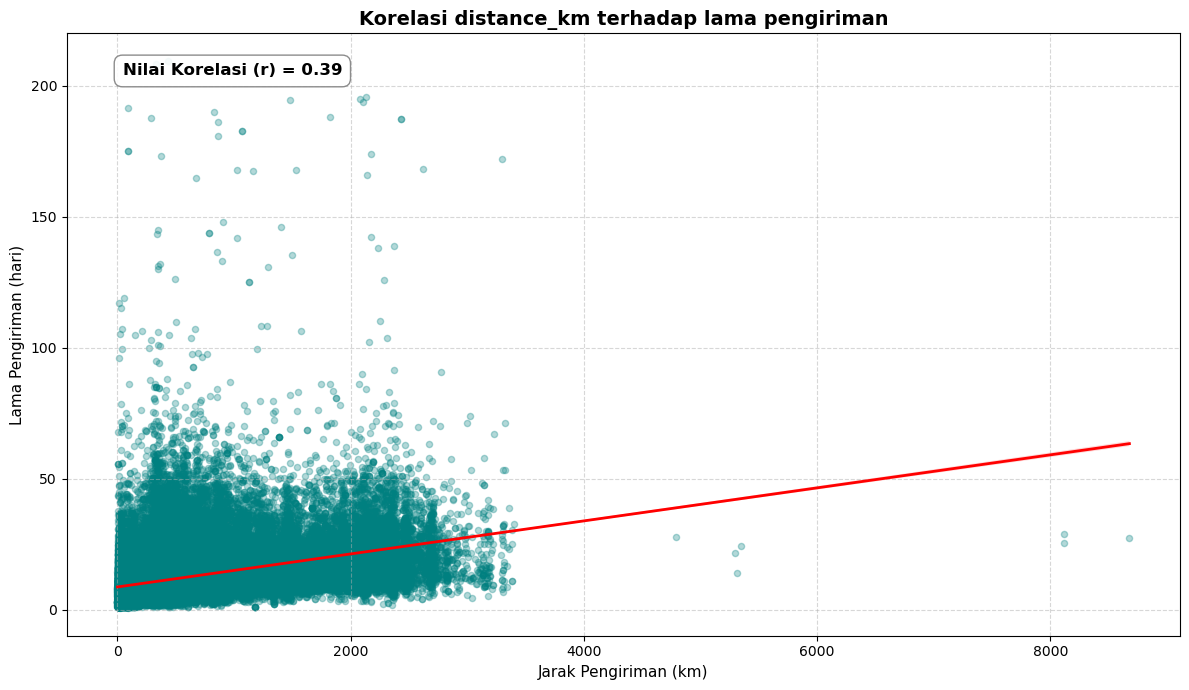

In [107]:
# 1. Menghitung nilai korelasi Pearson secara matematis
korelasi = cor_data_q3['distance_km'].corr(cor_data_q3['lama_pengiriman'])

plt.figure(figsize=(12, 7))

# 2. Menggunakan regplot untuk menampilkan scatter sekaligus garis tren
sns.regplot(
    data=cor_data_q3,
    x='distance_km', 
    y='lama_pengiriman',
    scatter_kws={'alpha': 0.3, 's': 20, 'color': 'teal'}, # Pengaturan untuk titik (scatter)
    line_kws={'color': 'red', 'linewidth': 2}             # Pengaturan untuk garis tren
)

# 3. Menambahkan kotak teks berisi angka korelasi di sudut plot
plt.gca().text(
    0.05, 0.95, # Posisi teks relatif terhadap ukuran sumbu (X=5% dari kiri, Y=95% dari bawah)
    f'Nilai Korelasi (r) = {korelasi:.2f}', 
    transform=plt.gca().transAxes, 
    fontsize=12,
    fontweight='bold',
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
)

# 4. Judul dan Label Sumbu
plt.title('Korelasi distance_km terhadap lama pengiriman', fontsize=14, fontweight='bold')
plt.xlabel('Jarak Pengiriman (km)', fontsize=11)
plt.ylabel('Lama Pengiriman (hari)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### KEY INSIGHT

Setelah dilakukan analisis korelasi antara `distance_km` dan `lama_pengiriman`, diperoleh nilai korelasi sebesar **0,0,393434**. Nilai tersebut menunjukkan adanya **korelasi positif dengan tingkat kekuatan lemah** berdasarkan pembagian lima tingkat interpretasi korelasi yang digunakan.Hal ini menunjukkan bahwa jarak geografis seller–customer yang lebih jauh cenderung berkaitan dengan waktu pengiriman yang lebih lama.

## KEY FINDINGS

1. State `SP` merupakan state dengan total revenue tertinggi dengan total revenue **R$5.067.633,16**

2. State `RJ` merupakan state dengan total revenue tertinggi kedua dengan total revenue **R$1.759.651,13**
3. State `SP` merupakan state dengan persentase revenue tertinggi dengan persentase revenue **38,3287%**
4. State `RJ` merupakan state dengan persentase revenue tertinggi kedua dengan total revenue **13,3090%**
5. Setelah dilakukan analisis korelasi antara `distance_km` dan `lama_pengiriman`, diperoleh nilai korelasi sebesar **0,0,393434**. Nilai tersebut menunjukkan adanya **korelasi positif dengan tingkat kekuatan lemah** berdasarkan pembagian lima tingkat interpretasi korelasi yang digunakan.Hal ini menunjukkan bahwa jarak geografis seller–customer yang lebih jauh cenderung berkaitan dengan waktu pengiriman yang lebih lama.


## BUSINESS IMPLICATIONS

1. SP dan RJ menyumbang kontribusi revenue terbesar, sehingga performa penjualan, ketersediaan produk, dan kualitas layanan di kedua state tersebut perlu dipantau secara konsisten untuk menjaga kontribusi terhadap revenue.

2. Tingginya kontribusi revenue dari SP dan RJ dapat menjadi pertimbangan dalam perencanaan distribusi, kapasitas fulfillment, dan penempatan seller agar operasional dapat mendukung area dengan aktivitas bisnis yang tinggi.

3. Korelasi positif antara `distance_km` dan `lama_pengiriman` menunjukkan bahwa jarak dapat menjadi salah satu faktor yang perlu diperhatikan dalam monitoring delivery performance. Namun, karena korelasi tidak menunjukkan sebab-akibat, evaluasi sebaiknya juga mempertimbangkan faktor lain seperti seller, carrier, fulfillment process, dan kondisi operasional.

4. Order dengan estimasi jarak geografis yang lebih jauh dapat dipantau secara khusus untuk melihat apakah terdapat pola waktu pengiriman yang berbeda dibandingkan order dengan jarak lebih dekat. Hal ini dapat membantu bisnis mengidentifikasi area yang membutuhkan evaluasi operasional lebih lanjut.
